# **Circular Data** 

### Import libraries

In [214]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from scipy.stats import gaussian_kde, vonmises
import traceback

import pycircstat2.hypothesis as circ


### Data Preparation for Processing

**Load data:**

In [215]:
data = pd.read_csv(r"C:\Users\modri\Downloads\Track stats 2026-04-27 (1).csv")
data

,Condition,Replicate,Track ID,Track UID,Track length,Speed min,Speed max,Speed mean,Speed sd,Speed median,...,Track end time,Mean straight line speed,Forward progression linearity,Direction mean,Direction var,Mean directional change,Mean directional change rate,Track displacement,Straightness ratio,Track points
0,CXCL12,1,1.0,1,209.331875,0.000000,0.157770,0.027689,0.028237,0.021473,...,8010.0,0.003591,0.137413,0.199245,0.846291,80.851038,0.010569,27.472120,0.131237,85
1,CXCL12,1,7.0,7,129.657961,0.000000,0.143478,0.032742,0.031787,0.020770,...,3960.0,0.008968,0.273909,1.786197,0.847041,90.590068,0.022368,36.321576,0.280134,45
2,CXCL12,1,8.0,8,251.889507,0.000000,0.110348,0.038872,0.028824,0.033818,...,6570.0,0.010274,0.267986,1.326369,0.782342,71.114766,0.010824,67.502891,0.267986,73
3,CXCL12,1,120.0,120,139.828399,0.008202,0.124120,0.057543,0.029270,0.052519,...,2430.0,0.013589,0.236156,1.450381,0.780220,77.604557,0.030795,34.244310,0.244902,28
4,CXCL12,1,162.0,162,182.509244,0.000000,0.098766,0.030725,0.023855,0.020770,...,6480.0,0.007107,0.252322,0.864194,0.845868,87.296727,0.014477,42.853100,0.234800,67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
649,CXCL12,3,2_73.0,8665,192.923987,0.000000,0.176106,0.030192,0.029638,0.023199,...,6390.0,0.008167,0.270513,2.471029,0.865494,90.062091,0.013898,52.923535,0.274323,72
650,CXCL12,3,2_77.0,8669,289.809988,0.000000,0.147865,0.036592,0.026592,0.029573,...,8010.0,0.005866,0.162139,0.440505,0.902653,89.707486,0.011199,46.989628,0.162139,89
651,CXCL12,3,2_80.0,8673,294.704436,0.000000,0.128121,0.036792,0.028935,0.029573,...,8010.0,0.009165,0.249109,1.045537,0.864930,80.622346,0.009953,74.238427,0.251908,90
652,CXCL12,3,2_81.0,8674,240.140204,0.000000,0.143478,0.029980,0.024806,0.023199,...,8010.0,0.006421,0.214174,0.114646,0.845154,94.128521,0.011621,52.009560,0.216580,90


**Dummie (simulated) data:**

In [216]:
test_data_random = np.linspace(np.deg2rad(0), 2 * np.pi, 2500, endpoint=False)          # random data
test_data_single = np.linspace(np.deg2rad(90), np.deg2rad(90), 2500, endpoint=False)    # single value data
test_data_biased = np.random.vonmises(mu=np.deg2rad(90), kappa=10, size=2500)           # biased data

**Automation helper dicionary:**

In [217]:
all_angles = data["Direction mean"].values
rep_angles = {n: data.loc[data["Replicate"] == n, "Direction mean"].values for n in range(1, 4)}

group_angles = {
    "All": all_angles,
    **{f"{n}": angles for n, angles in rep_angles.items()},
    "Random": test_data_random,
    "Single": test_data_single,
    "Bias": test_data_biased
}


## Plotting functions

**Save to SVG function:**

In [218]:
def save_svg(fig: plt.Figure, filename: str):
    fig.savefig(filename, format='svg', bbox_inches='tight')

**Classical ploar distribution plot:**

In [219]:
def classic_polar_dist(data: pd.Series, *, bins: int = 72, kappa: float = 25, ratio: float = 0.4, title_suffix: str = '', fig=None, ax=None) -> plt.Figure:
    
    # Wrap angles
    a = np.asarray(data, dtype=float)
    a = a % (2 * np.pi)

    check = np.isfinite(a)
    angles = a[check]

    # Create polar plot
    if fig is None or ax is None:
        fig, ax = plt.subplots(subplot_kw={"projection": "polar"})
    # ax.set_theta_zero_location("N")
    # ax.set_theta_direction(-1)
    ax.set_axis_off()

    # Rose histogram
    edges = np.linspace(0, 2 * np.pi, bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    widths = np.diff(edges)

    if angles.size > 0:
        counts, _ = np.histogram(angles, bins=edges)
        counts = counts.astype(float)
        if counts.max() > 0:
            counts /= counts.max()
    else:
        counts = np.zeros(bins, dtype=float)

    base_radius = 1
    hist_band = ratio
    bar_heights = counts * hist_band

    theta_circle = np.linspace(0, 2 * np.pi, 720, endpoint=False)
    ax.plot(theta_circle, np.full_like(theta_circle, base_radius-0.02),
            color="#C9CCCD", lw=1.25, zorder=2)

    ax.bar(
        centers,
        bar_heights,
        width=widths,
        bottom=base_radius,
        align="center",
        color="#72b2df",
        edgecolor="white",
        linewidth=0.7,
        alpha=0.95,
        zorder=3
    )

    # Density estimation using von Mises distribution
    n = 1440
    if angles.size < 2:
        theta = np.linspace(-np.pi, np.pi, n, endpoint=False)
        density = np.zeros(n, dtype=float)
    else:
        theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
        density = np.mean(
            vonmises.pdf(theta[:, None], kappa, loc=angles),
            axis=1
        )
        density = density - (density.max()/2)

    density_offset = base_radius + hist_band + 0.05
    density_r = density + density_offset

    ax.plot(theta, density_r, color="#5f91d3", lw=1, zorder=5)

    # Adjust y-limits, axes and grid
    ax.set_ylim(0, float(np.nanmax(density_r) + 0.05) if density_r.size else 1.6)
    ax.set_yticklabels([])
    ax.grid(False)

    # Title and annotations (annotations positioned relative to title pad, not data/axes coords)
    title = ax.set_title(
        f"Circular distribution {title_suffix}",
        va='bottom',
        fontsize=10,
        fontweight='bold',
        pad=40
    )

    tx, ty = title.get_position()
    tform = title.get_transform()

    ax.text(
        tx, ty, f"kappa: {kappa}",
        transform=mpl.transforms.offset_copy(tform, fig=fig, x=0, y=-5, units='points'),
        ha='center', va='top', fontsize=9, fontweight='medium'
    )
    ax.text(
        tx, ty, f"n: {angles.size}",
        transform=mpl.transforms.offset_copy(tform, fig=fig, x=0, y=-18, units='points'),
        ha='center', va='top', fontsize=9, fontweight='medium'
    )

    ax.text(0, 0.8, "0°", ha="left", va="center", fontsize=8, fontweight="light")
    ax.text(np.pi / 2, 0.8, "90°", ha="center", va="bottom", fontsize=8, fontweight="light")
    ax.text(np.pi, 0.8, "180°", ha="center", va="top", fontsize=8, fontweight="light")
    ax.text(3 * np.pi / 2, 0.8, "270°", ha="center", va="top", fontsize=8, fontweight="light")

    return plt.gcf()


# kappa_25 = classic_polar_dist(all_angles, bins=72, kappa=25)
# kappa_150 = classic_polar_dist(all_angles, bins=72, kappa=150)

**Polar plot showing replicate circular means:**

In [220]:
def polar_rep_bullets(
    data: pd.DataFrame,
    *,
    marker_size: float = 5.0,
    title_suffix: str = "",
    rep_col: str = "Replicate",
    bullet_sep_deg: float = 4.0,   # min angular separation on a single ring
    bullet_step: float = 0.05,     # spacing between rings
    max_rings: int = 12,
    colors: list = None
) -> plt.Figure:
    data = data.copy()
    reps = data[rep_col].unique()
    
    # Assign colors
    def _rand_color():
        return f'#{np.random.randint(0, 0xFFFFFF):06x}'
    
    if colors is None:
        colors = {rep: _rand_color() for rep in reps}
    else:
        try:
            colors = {rep: colors[i % len(colors)] for i, rep in enumerate(reps)}   
        except Exception as e:
            print("Error processing colors:", e)
            traceback.print_exc()
            colors = {rep: _rand_color() for rep in reps}

    # Create polar plot
    fig, ax = plt.subplots(subplot_kw={"projection": "polar"})
    # ax.set_theta_zero_location("N")
    # ax.set_theta_direction(-1)
    ax.set_axis_off()

    # Compute circular means for each replicate
    rep_cir_means = {}
    for rep in reps:
        rep_angles = data.loc[data[rep_col] == rep, "Direction mean"].values
        rep_angles = np.asarray(rep_angles, dtype=float) % (2 * np.pi)
        rep_angles = rep_angles[np.isfinite(rep_angles)]
        if rep_angles.size > 0:
            rep_cir_means[rep] = np.arctan2(np.mean(np.sin(rep_angles)), np.mean(np.cos(rep_angles))) % (2 * np.pi)
        else:
            rep_cir_means[rep] = np.nan

    # Draw base circle
    base_radius = 0.975
    theta_circle = np.linspace(0, 2 * np.pi, 720, endpoint=False)
    ax.plot(theta_circle, np.full_like(theta_circle, base_radius - 0.02),
            color="#C9CCCD", lw=1.25, zorder=2)

    # Calculate bullet positions with collision avoidance
    min_sep = np.deg2rad(bullet_sep_deg)
    ring_thetas = [[] for _ in range(max_rings)]
    items = [(rep, th) for rep, th in rep_cir_means.items() if np.isfinite(th)]
    items.sort(key=lambda x: x[1])

    # Place bullets with collision avoidance
    def circ_diff(a: float, b: float) -> float:
        d = abs(a - b)
        return min(d, 2 * np.pi - d)
    
    max_used_ring = 0
    for rep, th in items:
        rep_n = data.loc[data[rep_col] == rep, "Direction mean"].size

        ring = None
        for i in range(max_rings):
            if all(circ_diff(th, t_old) >= min_sep for t_old in ring_thetas[i]):
                ring = i
                break
        if ring is None:
            ring = max_rings - 1  # fallback in case of high data density

        ring_thetas[ring].append(th)
        max_used_ring = max(max_used_ring, ring)
        r = base_radius + ring * marker_size / 90 + 0.035

        ax.plot(
            th, r, "o",
            color=colors[rep],
            markersize=marker_size,
            markeredgecolor="#F9F9F9",
            markeredgewidth=0.2,
            zorder=4
        )

    # Adjust y-limits, axes and grid
    ylim_top = max(1.6, base_radius + (max_used_ring + 1) * bullet_step + 0.5)
    ax.set_ylim(0, ylim_top)
    ax.set_yticklabels([])
    ax.grid(False)

    # Add total average arrow
    total_avg = np.arctan2(np.mean(np.sin(list(rep_cir_means.values()))), np.mean(np.cos(list(rep_cir_means.values())))) % (2 * np.pi)
    ax.annotate("", arrowprops=dict(arrowstyle="->", color="#5B6B7B", lw=1.25), xy=(total_avg, base_radius + 0.125), xytext=(total_avg, base_radius - 0.115))

    # Title and annotations
    ax.set_title(f"Circular distribution {title_suffix}", va="bottom", fontsize=10, fontweight="bold", pad=30)

    add = 0.3
    for _rep in reps:
        rep_n = data.loc[data[rep_col] == _rep, "Direction mean"].size
        at_angle = rep_cir_means[_rep]
        ax.text(np.deg2rad(90), ylim_top + add + 0.025, f"●                     ", ha="center", va="top", fontsize=9, fontweight="bold", color=colors[_rep])
        ax.text(np.deg2rad(90), ylim_top + add, f"      {np.rad2deg(at_angle):.1f}°  (n: {rep_n})", ha="center", va="top", fontsize=8, fontweight="medium")
        add -= 0.145

    ax.annotate('', xy=(np.deg2rad(104.3), ylim_top - 0.04), xytext=(np.deg2rad(107), ylim_top + add - 0.04), textcoords='data', arrowprops=dict(arrowstyle="->", color="#5B6B7B", lw=1.25), zorder=6)
    ax.text(np.deg2rad(90), ylim_top + (0.3 - 0.145*3), f"              Total average: {np.rad2deg(total_avg):.1f}°", ha="center", va="top", fontsize=8, fontweight="medium")

    ax.text(0, 0.8, "0°", ha="left", va="center", fontsize=8, fontweight="light")
    ax.text(np.pi / 2, 0.8, "90°", ha="center", va="bottom", fontsize=8, fontweight="light")
    ax.text(np.pi, 0.8, "180°", ha="center", va="top", fontsize=8, fontweight="light")
    ax.text(3 * np.pi / 2, 0.8, "270°", ha="center", va="top", fontsize=8, fontweight="light")

    return plt.gcf()


## Plot generation and SVG export 

**Bullet polar plot:**

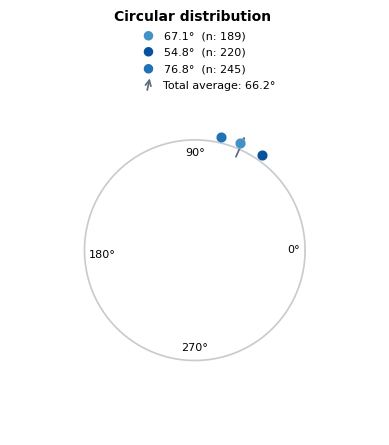

In [221]:
plot = polar_rep_bullets(data, marker_size=7.5, colors = ["#4292c6", "#08519c", "#2171b5"])
save_svg(plot, "replicate_bullets.svg")

**Classical distribution for all data groups:**

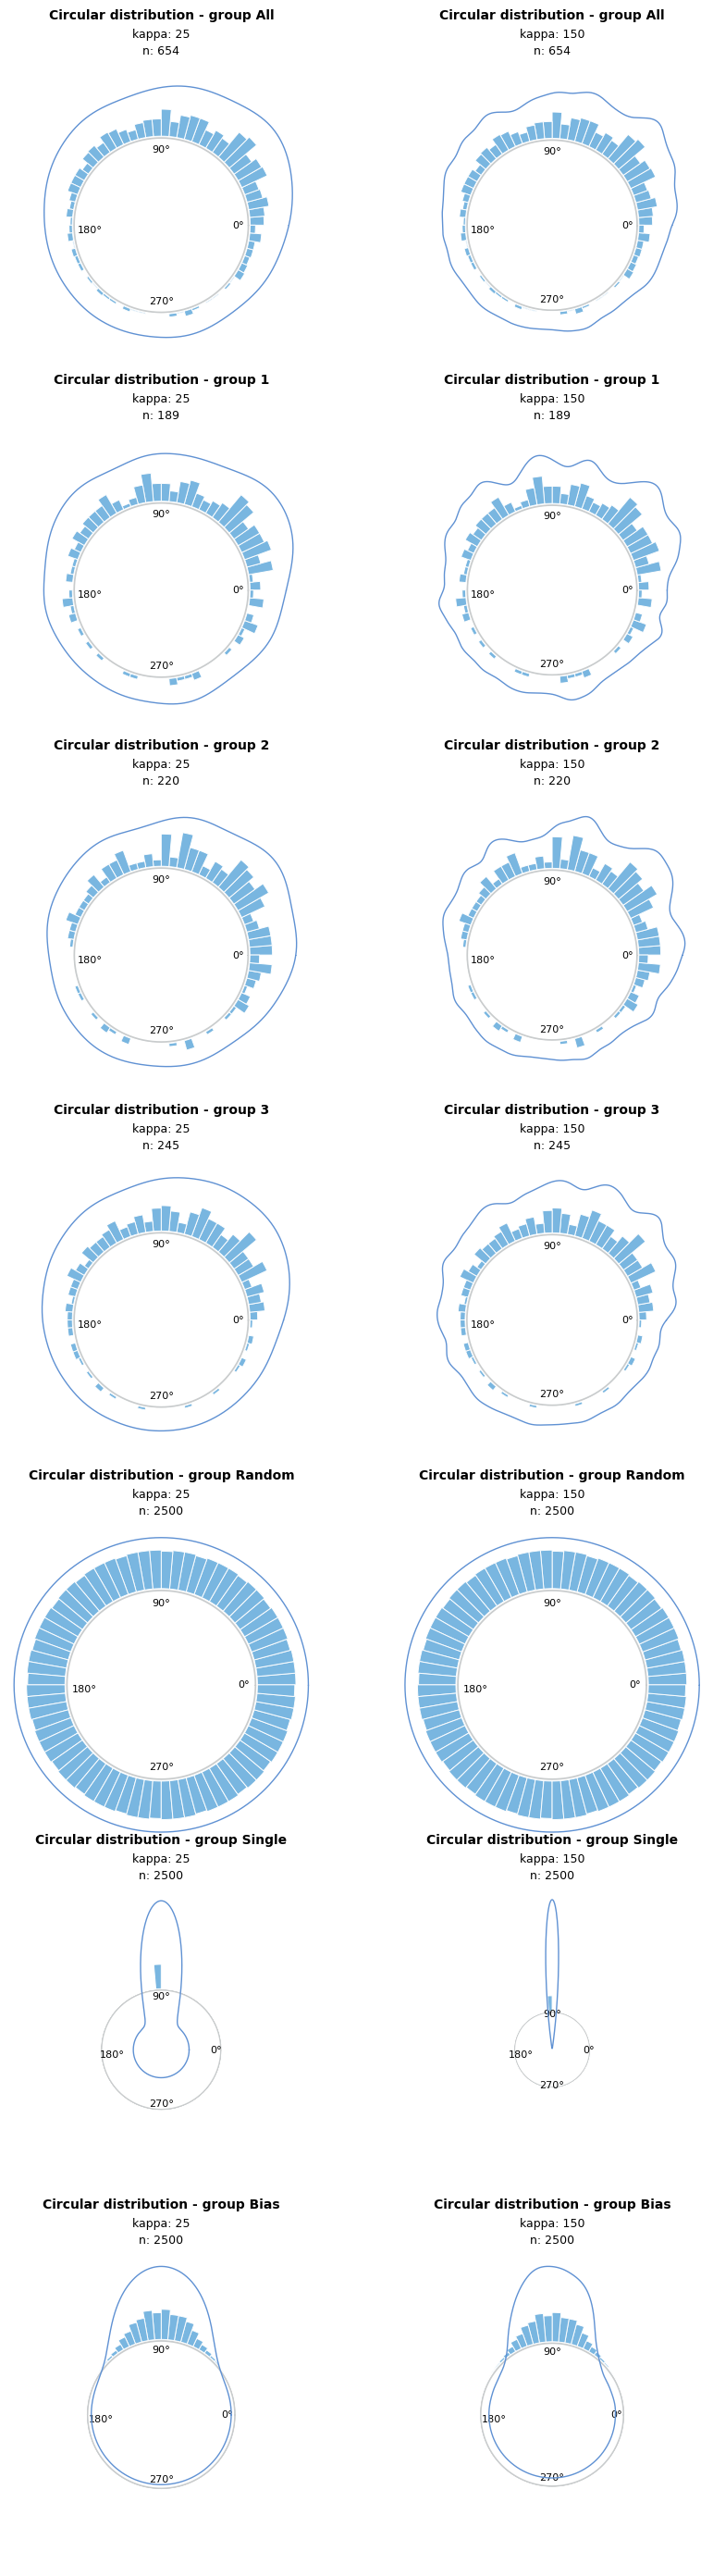

In [222]:
fig, ax = plt.subplots(nrows=len(group_angles), ncols=2,subplot_kw={"projection": "polar"}, figsize=(10, 5 * len(group_angles)), squeeze=False)

for group, angles in group_angles.items():
    if not hasattr(fig, "_axes_grid"):
        fig._axes_grid = np.atleast_2d(ax)
        fig._plot_row = 0

    row_axes = fig._axes_grid[fig._plot_row]
    fig = classic_polar_dist(
        angles,
        bins=72,
        kappa=25,
        title_suffix=f"- group {group}",
        fig=fig,
        ax=row_axes[0]
    )
    ax = row_axes[1]
    fig._plot_row += 1
    fig = classic_polar_dist(angles, bins=72, kappa=150, title_suffix=f"- group {group}", fig=fig, ax=ax)
    

In [ ]:
for group, angles in group_angles.items():
    save_svg(classic_polar_dist(angles, bins=72, kappa=25,  title_suffix=f"- group {group}"), f"Classical polar - group_{group} - kappa_25.svg")
    save_svg(classic_polar_dist(angles, bins=72, kappa=150, title_suffix=f"- group {group}"), f"Classical polar - group_{group} - kappa_150.svg")

# **Statistical tests** (Circular Data)

### **Rayleigh test:**
***testing uniformity** <- whether are the data distributed uniformly around a circle*

In [224]:
print("Rayleigh test results:\n")
for group, angles in group_angles.items():
    result = circ.rayleigh_test(angles)
    print(f"Group {group}\n  r: {result.r:.5f}\n  z: {result.z:.5f}\n  pval: {result.pval:.5f}\n")


Rayleigh test results:

Group All
  r: 0.56928
  z: 211.94484
  pval: 0.00000

Group 1
  r: 0.52950
  z: 52.99089
  pval: 0.00000

Group 2
  r: 0.57205
  z: 71.99200
  pval: 0.00000

Group 3
  r: 0.61805
  z: 93.58634
  pval: 0.00000

Group Random
  r: 0.00000
  z: 0.00000
  pval: 1.00000

Group Single
  r: 1.00000
  z: 2500.00000
  pval: 0.00000

Group Bias
  r: 0.94855
  z: 2249.36795
  pval: 0.00000



### **V-Test:**
***testing bias** <- whether are angles biased towards the given (expected) 0° value* 

In [225]:
print("V-test results:\n")
for group, angles in group_angles.items():
    result = circ.V_test(np.deg2rad(0), angles)
    print(f"Group {group}\n  V: {result.V:.5f}\n  u: {result.u:.5f}\n  pval: {result.pval:.5f}\n")

V-test results:

Group All
  V: 146.09457
  u: 8.07905
  pval: 0.00000

Group 1
  V: 39.01389
  u: 4.01332
  pval: 0.00003

Group 2
  V: 72.50707
  u: 6.91328
  pval: 0.00000

Group 3
  V: 34.57362
  u: 3.12375
  pval: 0.00089

Group Random
  V: nan
  u: nan
  pval: nan

Group Single
  V: 0.00000
  u: 0.00000
  pval: 0.50000

Group Bias
  V: 0.31318
  u: 0.00886
  pval: 0.49647



### **Watson-Williamns test across replicates:**
***testing reproducibility** <- whether are there significant differences between replicates*

In [226]:
result = circ.watson_williams_test([angles for angles in rep_angles.values() if angles.size > 0])
result
print(f"Watson-Williams test:\n  F: {result.F:.5f}\n  pval: {result.pval:.5f}\n  df_between: {result.df_between}\n  df_within: {result.df_within}\n  k: {result.k}\n  N: {result.N}\n")

Watson-Williams test:
  F: 7.50098
  pval: 0.00060
  df_between: 2
  df_within: 651
  k: 3
  N: 654



# **Statistical tests** (Linear Data)

### Import libraries

In [227]:
from scipy import stats

### Data Preparation

**Load Data:**

In [228]:
data_lin = pd.read_csv(r"C:\Users\modri\Downloads\Track stats 2026-04-23.csv")
data_lin

,Condition,Replicate,Track ID,Track UID,Track length,Speed min,Speed max,Speed mean,Speed sd,Speed median,...,Forward progression linearity,Direction mean,Direction var,Mean directional change,Mean directional change rate,Track displacement,Straightness ratio,Track points,Replicate color,Condition color
0,DMSO,1,6_0.0,0,114.010562,0.037773,0.155048,0.096619,0.029082,0.097121,...,0.800846,-2.527010,0.198404,19.461872,0.016218,92.852390,0.814419,60,#eae2b7,#000000
1,DMSO,1,6_1.0,1,122.710919,0.022674,0.240041,0.103992,0.057410,0.095117,...,0.250209,2.702753,0.746661,46.148295,0.038457,31.223732,0.254450,60,#eae2b7,#000000
2,DMSO,1,6_10.0,2,60.434857,0.006592,0.125855,0.051216,0.026095,0.051198,...,0.524950,2.371453,0.553058,42.487993,0.035407,32.263009,0.533848,60,#eae2b7,#000000
3,DMSO,1,6_100.0,3,109.771937,0.034469,0.278198,0.093027,0.042969,0.084068,...,0.764341,2.407828,0.228382,20.309142,0.016924,85.325281,0.777296,60,#eae2b7,#000000
4,DMSO,1,6_101.0,4,117.404701,0.025701,0.206076,0.099496,0.038083,0.104158,...,0.775624,-1.874993,0.216768,22.607436,0.018840,92.605306,0.788770,60,#eae2b7,#000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4760,compound C 0.3 μM,4,4_95.0,3995,56.400155,0.007529,0.091687,0.047797,0.022868,0.048734,...,0.219468,1.841330,0.902840,46.959137,0.039133,12.587840,0.223188,60,#b5171a,#85ed7e
4761,compound C 0.3 μM,4,4_96.0,3996,125.963240,0.006004,0.279149,0.106749,0.075973,0.101061,...,0.654417,2.126420,0.462430,35.043024,0.029203,83.829635,0.665509,60,#b5171a,#85ed7e
4762,compound C 0.3 μM,4,4_97.0,3997,241.399765,0.011637,0.414943,0.204576,0.108899,0.218236,...,0.596527,-1.931377,0.609739,23.296700,0.019414,146.442234,0.606638,60,#b5171a,#85ed7e
4763,compound C 0.3 μM,4,4_98.0,3998,232.772769,0.025397,0.376875,0.197265,0.093072,0.208606,...,0.619101,2.437919,0.380240,31.472305,0.026227,146.552361,0.629594,60,#b5171a,#85ed7e


**Prepare data for automated processing:**

In [229]:
categories = {}

for cond in data_lin["Condition"].unique():
    cond_data = data_lin.loc[data_lin["Condition"] == cond]
    replicates = {}
    for rep in cond_data["Replicate"].unique():
        rep_data = cond_data.loc[cond_data["Replicate"] == rep]
        replicates.update({rep: rep_data})
    categories.update({cond: {'cond_data': cond_data, 'rep_data': replicates}})


## **tests:**

### **One way ANOVA test** :

*H0 = groups have the same population mean* <- `scipy.stats.f_oneway()`

### **Dunette test:** 

*Testing difference significance between two groups (of replicate medians) - comparing a selected group to the control group:*  <- `scipy.stats.dunnette()`

In [ ]:
data_cols = ["Track displacement", "Max distance reached", "Track length", "Speed mean", "Mean directional change", "Mean directional change rate", "Direction var", "Straightness ratio", "Mean straight line speed", "Forward progression linearity"]

significant_comparisons = {}
compare_to = 'DMSO'

for data_col in data_cols:

    for cond, data in categories.items():
        if cond == compare_to:
            continue
        cond_data = data['cond_data']
        values_control = categories[compare_to]['cond_data'][categories[compare_to]['cond_data']['Condition'] == compare_to][data_col].dropna().values
        values_cond = cond_data[cond_data['Condition'] == cond][data_col].dropna().values

    for key, data in categories.items():
        _rep_data = data['rep_data']
        for rep, rep_data in _rep_data.items():
            median = rep_data[data_col].dropna().median()

    _rep_medians = [[rep_data[data_col].dropna().median() for rep, rep_data in data['rep_data'].items()] for key, data in categories.items()]

    anovaresult = stats.f_oneway(*_rep_medians)
    print(f"ANOVA test results:\n  pvalue: {anovaresult.pvalue:.5f}\n  statistic: {anovaresult.statistic:.5f}\n")

    if anovaresult.pvalue < 0.05:
        dunettes_result = stats.dunnett(*_rep_medians[1:], control=_rep_medians[0])
        print(dunettes_result)
        
        print(f"Control = {list(categories.keys())[0]}")
        for sample in range(len(categories)-1):
            print(f"Sample {sample} = {list(categories.keys())[sample+1]}")

        significant_comparisons[data_col] = {
            "anova_result": anovaresult,
            "dunette_result": dunettes_result
        }

    else:
        print("ANOVA did not show significant differences between groups, skipping Dunnett's test.")

    

ANOVA test results:
  pvalue: 0.05439
  statistic: 2.70120

ANOVA did not show significant differences between groups, skipping Dunnett's test.
ANOVA test results:
  pvalue: 0.02134
  statistic: 3.52618

Dunnett's test (95.0% Confidence Interval)
Comparison               Statistic  p-value  Lower CI  Upper CI
 (Sample 0 - Control)     -3.472     0.011   -47.086    -5.373
 (Sample 1 - Control)     -3.119     0.024   -44.422    -2.709
 (Sample 2 - Control)     -2.366     0.108   -38.728     2.985
 (Sample 3 - Control)     -3.158     0.022   -44.711    -2.998
 (Sample 4 - Control)     -1.434     0.488   -31.686    10.027

Control = DMSO
Sample 0 = compound A 10 μM
Sample 1 = compound B 10 μM
Sample 2 = compound B 3 μM
Sample 3 = compound C 3 μM
Sample 4 = compound C 0.3 μM
ANOVA test results:
  pvalue: 0.00909
  statistic: 4.34217

Dunnett's test (95.0% Confidence Interval)
Comparison               Statistic  p-value  Lower CI  Upper CI
 (Sample 0 - Control)     -3.444     0.012   -79.211

## **Results** - properties where ANOVA tested >0.05 with details regarding the Dunnette's test:

In [247]:
for property, result in significant_comparisons.items():
    print(f"\nSignificant comparisons for '{property}' (ANOVA pval: {result['anova_result'].pvalue:.4f}):\n")
    print(result['dunette_result'])

print(f"Control = {list(categories.keys())[0]}")
for sample in range(len(categories)-1):
    print(f"Sample {sample} = {list(categories.keys())[sample+1]}")


Significant comparisons for 'Max distance reached' (ANOVA pval: 0.0213):

Dunnett's test (95.0% Confidence Interval)
Comparison               Statistic  p-value  Lower CI  Upper CI
 (Sample 0 - Control)     -3.472     0.011   -47.086    -5.373
 (Sample 1 - Control)     -3.119     0.024   -44.422    -2.709
 (Sample 2 - Control)     -2.366     0.108   -38.728     2.985
 (Sample 3 - Control)     -3.158     0.022   -44.711    -2.998
 (Sample 4 - Control)     -1.434     0.488   -31.686    10.027


Significant comparisons for 'Track length' (ANOVA pval: 0.0091):

Dunnett's test (95.0% Confidence Interval)
Comparison               Statistic  p-value  Lower CI  Upper CI
 (Sample 0 - Control)     -3.444     0.012   -79.211    -8.692
 (Sample 1 - Control)     -3.486     0.011   -79.751    -9.231
 (Sample 2 - Control)     -2.762     0.050   -70.516     0.004
 (Sample 3 - Control)     -3.596     0.009   -81.159   -10.639
 (Sample 4 - Control)     -1.274     0.592   -51.518    19.001


Significant